In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv('Hydrology_Engine_training .csv')

DESCRIBING THE STRUCTURE OF DATA

In [28]:
df.shape

(1913317, 6)

In [29]:
df.head()

,lat,lon,elevation_m,rain_95p_mm,drain_present,drain_density
0,28.884429,77.075732,216.0,18.516111,0,0.0
1,28.884429,77.076001,216.0,18.516111,0,0.0
2,28.884159,77.075193,217.0,18.516111,0,0.0
3,28.884159,77.075462,216.0,18.516111,0,0.0
4,28.884159,77.075732,216.0,18.516111,0,0.0


In [30]:
df.tail()

,lat,lon,elevation_m,rain_95p_mm,drain_present,drain_density
1913312,28.408771,77.167090,299.0,13.391333,0,0.0
1913313,28.408771,77.167360,299.0,13.391333,0,0.0
1913314,28.408501,77.165743,296.0,13.391333,0,0.0
1913315,28.408501,77.166012,295.0,13.391333,0,0.0
1913316,28.408501,77.166282,294.0,13.391333,0,0.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913317 entries, 0 to 1913316
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   lat            float64
 1   lon            float64
 2   elevation_m    float64
 3   rain_95p_mm    float64
 4   drain_present  int64  
 5   drain_density  float64
dtypes: float64(5), int64(1)
memory usage: 87.6 MB


In [32]:
df.describe()

,lat,lon,elevation_m,rain_95p_mm,drain_present,drain_density
count,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06,1.913317e+06
mean,2.864651e+01,7.710896e+01,2.216507e+02,1.512571e+01,1.031768e-02,8.362028e-01
std,1.078974e-01,1.138555e-01,1.807152e+01,4.577235e+00,1.010507e-01,2.694791e+00
min,2.840850e+01,7.683292e+01,1.710000e+02,8.075898e+00,0.000000e+00,0.000000e+00
25%,2.856211e+01,7.702075e+01,2.120000e+02,1.339133e+01,0.000000e+00,0.000000e+00
50%,2.863784e+01,7.711750e+01,2.150000e+02,1.851611e+01,0.000000e+00,0.000000e+00
75%,2.873028e+01,7.719727e+01,2.220000e+02,1.851611e+01,0.000000e+00,0.000000e+00
max,2.888443e+01,7.733768e+01,3.130000e+02,1.992489e+01,1.000000e+00,6.000000e+01


MISSING VALUE CHECK ON DATASET

In [33]:
df.isnull().sum()

,0
lat,0
lon,0
elevation_m,0
rain_95p_mm,0
drain_present,0
drain_density,0



**Spatial Rainfall Map:**
The map illustrates the spatial distribution of rainfall across the region using latitude and longitude coordinates, where different colors represent different rainfall intensities. The **dark red region in the southwest** indicates the **highest rainfall**, approximately **19–20 mm**. The **orange/red region in the northwest** shows **high rainfall**, around **17–18 mm**, which is slightly lower than the southwest. In contrast, the **dark blue region in the northeast** represents the **lowest rainfall**, approximately **8–10 mm**, suggesting relatively drier conditions. Meanwhile, the **light grey/blue region in the southeast** indicates **moderate rainfall**, ranging from **12–14 mm**.







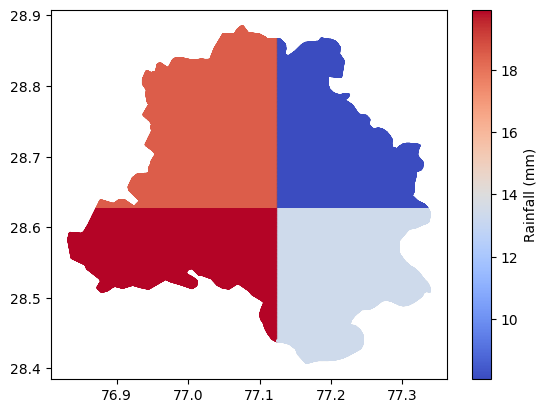

In [34]:
plt.scatter(df['lon'], df['lat'], c=df['rain_95p_mm'], cmap='coolwarm', s=1)
plt.colorbar(label="Rainfall (mm)")
plt.show()

Elevation VS Rainfall Scatter Plot:

The scatter plot reveals that rainfall values cluster around a few discrete levels rather than varying continuously with elevation. Although elevation spans a range from about 180 m to 310 m, rainfall does not show a clear linear increase or decrease with elevation. Instead, rainfall tends to occur in distinct bands, indicating possible categorization or measurement grouping in the data.


<Axes: xlabel='elevation_m', ylabel='rain_95p_mm'>

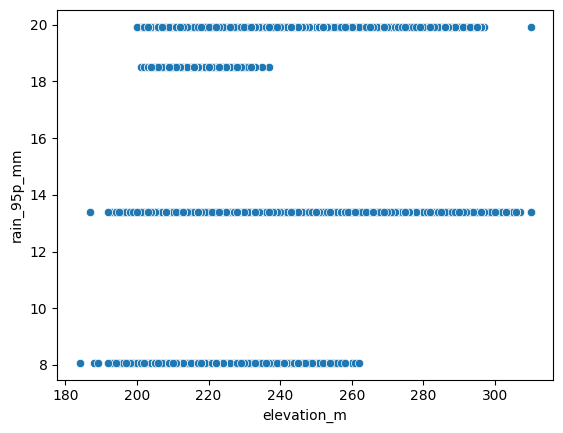

In [36]:
sns.scatterplot(
    x='elevation_m',
    y='rain_95p_mm',
    data=df.sample(50000)
)

Rainfall vs Drain Density Hexbin Plot:
The hexbin plot shows the density of data points for rainfall (rain_95p_mm) on the x-axis and drain density on the y-axis, with **darker blue indicating higher counts**. Most data points are concentrated at **very low drain density values between 0 and 1**. Rainfall values cluster around **four discrete levels: approximately 8 mm, 13.5 mm, 18.5 mm, and 20 mm**. The highest concentrations of observations occur near these rainfall levels with **drain density close to zero**. There are **very few instances where drain density exceeds 10**, and **almost none beyond 60**, indicating that **drain density remains low across most rainfall levels**.



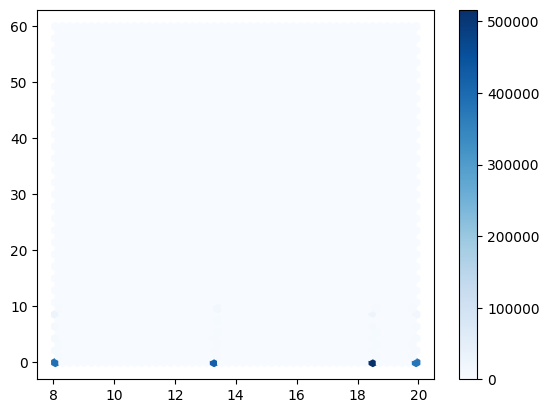

In [37]:
plt.hexbin(df['rain_95p_mm'], df['drain_density'], gridsize=50, cmap='Blues')
plt.colorbar()

Histogram of Elevation:
The **elevation values** range from approximately **170 m to 320 m**, with most areas concentrated between **200 m and 230 m**. The **highest frequency** occurs around **215–220 m**, indicating that the majority of the region lies at this elevation. The distribution is **right-skewed (positively skewed)**, showing a **long tail toward higher elevations (250–300+ m)**, while very few areas fall below **190 m** or above **280 m**.


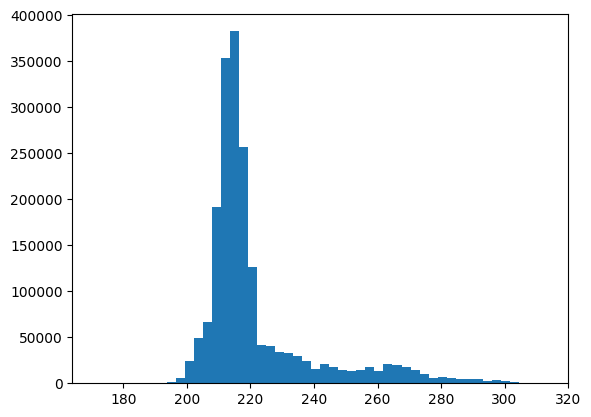

In [41]:
plt.hist(df['elevation_m'], bins=50)
plt.show()

Boxplot (Rainfall vs Drain Presence):
The boxplot compares **rainfall (rain_95p_mm)** between areas where a **drain is not present (0)** and **drain is present (1)**, showing that rainfall ranges from approximately **8 mm to 20 mm** in both groups. The **minimum, maximum, median, and interquartile range (IQR)** are nearly identical, indicating **similar spread and variability**. Overall, the **distribution pattern** is almost the same for both categories, with **no noticeable outliers**, suggesting that **drain presence does not significantly affect rainfall distribution**.


<Axes: xlabel='drain_present', ylabel='rain_95p_mm'>

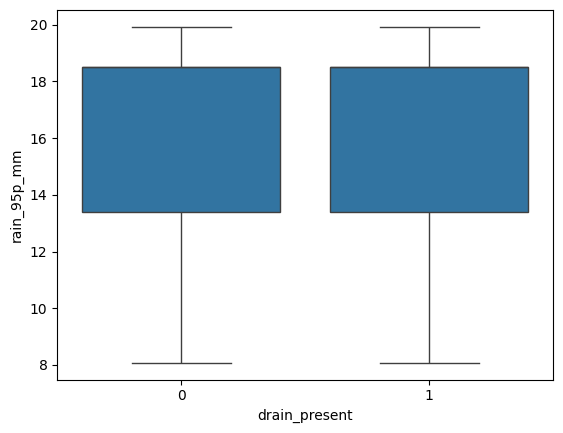

In [42]:
sns.boxplot(
    x='drain_present',
    y='rain_95p_mm',
    data=df.sample(100000)
)

Correlation Heatmap:
The **correlation heatmap** shows relationships among **elevation_m**, **rain_95p_mm**, and **drain_density**, where the diagonal values are **1** indicating **perfect self-correlation**. The correlations between variables are **very weak and negative** (−0.032, −0.11, −0.017), showing **no strong linear relationship** and This indicates flood risk depends on **combined environmental factors rather than a single variable**.


<Axes: >

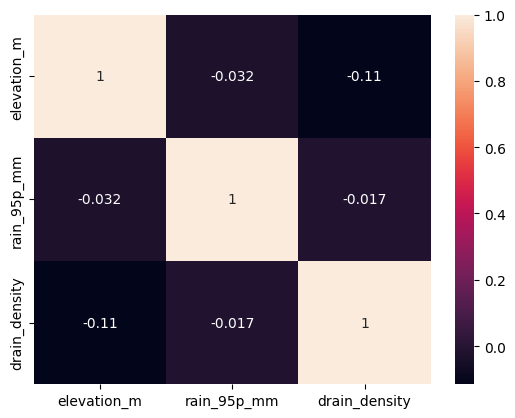

In [43]:
corr = df[['elevation_m','rain_95p_mm','drain_density']].corr()

sns.heatmap(corr, annot=True)